# RideWise - Churn Modelling & Evaluation

- Purpose: train another model to predict which rider will churn, evaluated their perfomrance and select the best

- We have like 10, 000 riders, about 10% will churn next month, which ones?
- Solution : Train a model that scores each rider 0-100% churn probability
- High score (80% +) Urgent intenvention
- Medium score (40-80%) monitor closely
- Low score (<40%) stable, maintain quality service

- Logistic regression (Simple, fast, interpretable)  -- Baseline model
- random forest classifier --- More robust, handle non-linear relationship
- Xgboost ----- Often best performance(advanced model) --- handle imbalanced dataset very well

#### Step 1 Setup and Load data

In [1]:
import os, warnings, joblib
import os, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings("ignore")
%matplotlib inline
sns.set_theme(style="whitegrid", font_scale=1.2)


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# import our evaluation libraries
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    RocCurveDisplay, PrecisionRecallDisplay, confusion_matrix, precision_recall_curve
)
from xgboost import XGBClassifier


# Define our system location
# define the data paths
DATA_PROCESSED = os.path.join("..", "data", "processed")
MODEL_DIR = os.path.join("..", "models")
os.makedirs(MODEL_DIR, exist_ok=True)

features = pd.read_csv(os.path.join(DATA_PROCESSED, "features.csv"))
segment_df = pd.read_csv(os.path.join(DATA_PROCESSED, "segment_assignment.csv"))

### Step 2 - Prepare our Data

In [2]:
df = features
df.head()

,user_id,churned,days_since_last_trip,days_since_last_session,trips_last_7d,trips_last_30d,trips_last_60d,trips_last_90d,monetary_total,monetary_avg,...,avg_pages_visited,session_conversation_rate,engagement_score,account_age_days,activity_trend_30d,unique_active_days,was_referred,avg_rating_given,loyalty_encoded,city_encoded
0,R00000,0,25,0.0,0,1,1,3,414.13,16.57,...,3.00,0.25,276.00,93,0.50,25,1,5.0,0,0
1,R00001,1,5,0.0,1,2,3,3,195.69,13.98,...,2.67,0.00,466.37,230,0.67,13,0,4.7,0,0
2,R00002,1,14,0.0,0,1,4,5,482.94,20.12,...,3.00,0.00,573.00,232,0.50,22,0,4.2,0,1
3,R00004,0,12,0.0,0,2,2,5,391.15,24.45,...,2.50,0.00,42.50,250,0.67,16,1,3.9,1,1
4,R00005,0,2,0.0,1,2,2,4,300.63,15.82,...,1.67,0.17,50.65,657,0.67,19,0,5.0,0,1


In [3]:
# Drop the churn columns
# Cant train a model without knowing the true label

df = features.dropna(subset=["churned"]).copy()
churn_rate = df["churned"].mean()
print(f"Riders : {len(df):,}")
print(f"Churned: {df['churned'].sum():,} ({churn_rate * 100: 1f}%)")

Riders : 9,204
Churned: 989 ( 10.745328%)


In [4]:
# 10% churned is slightly imbalanced but managable
# <5% or > 40%
# well use class_weight="balanced"

### Step 2 - Features & Train/Test split

In [5]:
# Step 2a
# user id : identifier , not a pattern
# churned : Target label (can use the answer to predict itself)
EXCLUDE = ["user_id", "churned"]


# All 36 engineered features we'd keep
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE]

print(f"{len(FEATURE_COLS)} features selcted")
print(FEATURE_COLS)

36 features selcted
['days_since_last_trip', 'days_since_last_session', 'trips_last_7d', 'trips_last_30d', 'trips_last_60d', 'trips_last_90d', 'monetary_total', 'monetary_avg', 'trips_lifetime', 'monetary_last_30d', 'rfm_recency_score', 'rfm_frequency_score', 'rfm_monetary_score', 'rfm_combined_score', 'avg_trip_duration', 'avg_fare', 'avg_surge', 'tip_rate', 'peak_hour_rate', 'weekend_ratio', 'rainy_ride_ratio', 'preffered_payment_encoded', 'avg_driver_rating_received', 'session_last_30d', 'session_last_60d', 'avg_time_on_app', 'avg_pages_visited', 'session_conversation_rate', 'engagement_score', 'account_age_days', 'activity_trend_30d', 'unique_active_days', 'was_referred', 'avg_rating_given', 'loyalty_encoded', 'city_encoded']


In [6]:
# # Step 2b : prepare the array of data (X and Y)

X = df[FEATURE_COLS].values
y = df["churned"].values

# check the shape of these dataset
print(X.shape)
print(y.shape)

(9204, 36)
(9204,)


In [7]:
# Step 2c : Train/Test split

# test_size = 0.2 aka 20%
# 80% training data (8000 riders)
# 20 testing data (2000 riders)
# standard split ratio

# random_state =42
# everybody get same split
# any number can work

# stratify=y
# y = target variable == churn rate
# ensure the train and test have same churn rate
# without stratify : train 12% churn, test 8% === biased evaluation

#scale_pos_weight
# ratio of negative (active) to positive (churned) examples
# used by Xgboost to handle class imblance 
# formular = neg/post -- 7152/848 == 8.4
# tells model "churned riders are 8.4x rarer, weigh them 8.4x more "

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# scale postive weight
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
scale_pos = neg/pos

print (f"Train: {len(X_train):,}   Test:{len(X_test):,} | Scale_pos_weight: {scale_pos:.1f}")




Train: 7,363   Test:1,841 | Scale_pos_weight: 8.3


### Step 2b - Logistic Regression 

In [8]:
# Understand the 3 models 

# model : Logistic regression (Baseline model)

# image plotting riders on a graph 
# X = RF combined score
# Y = Churn probability 

# Logistic regression drawa a curved S-shaped line (seperate churned from Non chrned )

# class_weight = "balanced" : Automatically adjust for imbalances classes
# give more weight/coefficient to churned examples during training 
# formular = weight = n_samples/ (n_classes * class_count)

# max_iter = 500 : maximum iteration for optimization 
# default is 100, sometimes is not enough (converge)
# 
lr = LogisticRegression(class_weight="balanced", max_iter=500, random_state=42)




### Step 2c - Random Forest 

In [9]:
# Random Forest (ensemble method--- collection of decision trees)
# imagibe 200 experts , each of looking at random subset of your features
# Expert 1 : if recency_score < 3 AND trips_last_30d < 5 ---- churned
# Expert 2 : if session_conversion_rate < 0.2 AND activity_trend < 0.5 --- churned
# Expert 200 expert

# Final decision : Majority vote ..... if 100 out of the 200 expert says someone is going to churn == probability = 50%

# n_estimators=200 : builds 200 decision trees
# max_dept =  Each tree can be max 10 levels deep
# prevent overfitting (too deep = memorize the training data)
# n_jobs = -1 : use all CPU core for paralle training (faster)

rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight="balanced", random_state=42, n_jobs=-1
)


### Step 2d - XGboost

In [10]:
# XGBOOST
# Iterative Learner (Self correct itself)
# Start with a model thats dumb , predicts everyone's churn probability = 10% (average)

# Round 1
# Finds riders where model is most got it wrong
# builds a small tree to fix those mistakes
# updates the prediction slight


# Rounds 2 
# check ; whos still predicted wrongly 
# build another small tree to fix those mistakes
# updates the predictions again 

# Repeats 200 times ----- final model = sum of all the 200 trees


# n_estimatores = build 200 boosting rounds(trees)
# max_depth = 5 : shallower trees than Random forest
# XGBOOST use many small trees ; Random forest us fewer large trees
# learning_rate=0.05 : How much each tree contributes 
# lower -- more conservaitve, might generalize the training
# slow the training (more trees)
# scale pos weight === handle imbalance 
# eval_metric : optimization metricd (log loss for probabilities)

xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.05,
    scale_pos_weight=scale_pos, eval_metric="logloss", use_label_encoder=False,
    random_state=42, n_jobs=-1
)

### Step 2e - Training Process

In [11]:
MODELS = {"Logistic Regression":lr, "Random Forest":rf, "XGboost":xgb}

probas, preds = {},{}
for name, model in MODELS.items():
    model.fit(X_train, y_train)
    probas[name] = model.predict_proba(X_test)[:,1]
    preds[name] =  model.predict(X_test)

    print(
        f"{name:25s} AUC:{roc_auc_score(y_test, probas[name]):.4f}"
        f" F1:{f1_score(y_test, preds[name]):.4f}"
    )





Logistic Regression       AUC:0.4708 F1:0.1654
Random Forest             AUC:0.4673 F1:0.0000
XGboost                   AUC:0.4813 F1:0.1188


### Step 2f - ROC & Precision -Recall Curves

- Another form of evaluation metric
- Metric ROC-AUC (Receiver operating characteristic----- Area under CURVE)
- what does it measure ; ability to seperate all the classed across all threshold



##### AUC-ROC
- security at the airport want to scan you threat /drugs

- True Positive TP - Correctlt flagged 
- False Positive FP - incorrectly flagged as active (churned)
- True Negative TN - correctly flagged as active (Non churned)
- False Negative FN - missed churned 


#### ROC CURVE
- X-axis : False positive rate = FP/(FP + TN) (how many active riders did we wrongly predict that they'd churn)
- Y-axis : True positive rate = TP/(TP+ FN) (how manu not active rider did we catch)


###### PERFECT MODEL ; catchs all the churners (100% TPR) with zero false alarm (0% FPR)
###### RANDOM MODEL : Diagonal line (50% TPR, 50% FPR)


#### Step  2e : Precision Recall 
- what does it measure : Performance when classes are imbalance
- Why ROC isn't enough


#### E.g with 10.6% churn rate:
 - predict everyone as "active" ---- 89.5% accuracy
 - But only caught ZERO churners ---- 

- Precision Recall focus on the minority class (Churned 10.6%)
- Precision = TP/ (TP + FP) --------- out of everyone we predicted will churn (y_pred), how many actually did??? 
- High precision = few false alarm


##### Recall = TP/(TP + FN) ---- out of everyone who actually churned (churned column y_actual), how many did we catch
- High recall = we catch most churners


##### F1 Score = Balance
- F1 = 2 * (precision * recall) / (precision + recall)
- Harmonic mean of precision and recall to get F1 score 


#### ROC + Precision Recall curve

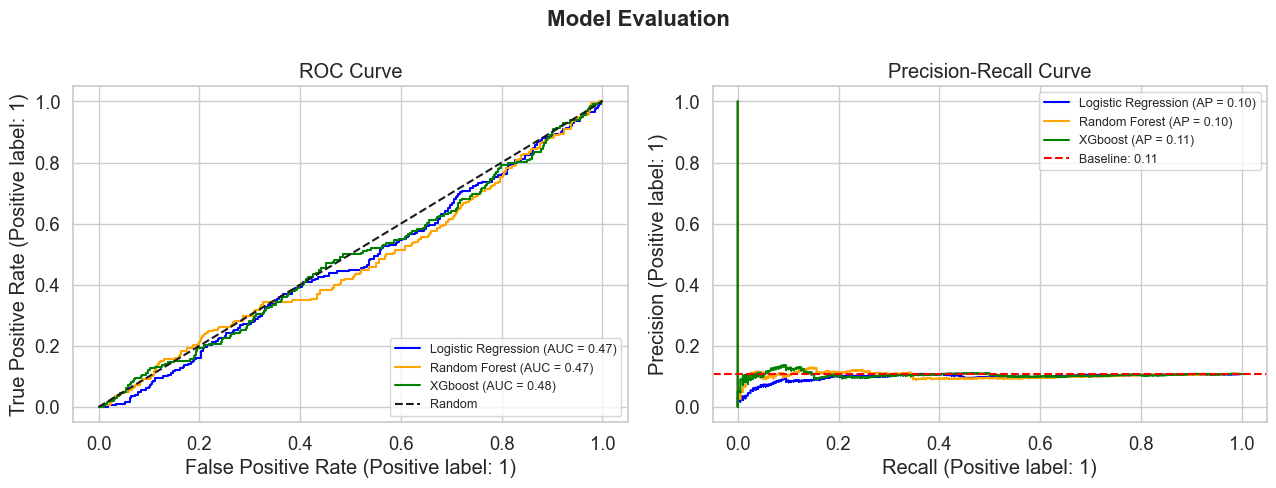

In [12]:
colors = ["blue", "orange", "green"]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for (name, proba), color in zip(probas.items(), colors):
    RocCurveDisplay.from_predictions(y_test, proba, name=name, ax=axes[0], color=color)
    PrecisionRecallDisplay.from_predictions(y_test, proba, name=name, ax=axes[1], color=color)


axes[0].plot([0,1], [0,1], "k--", label="Random")
axes[0].set_title("ROC Curve")
axes[0].legend(loc="lower right", fontsize=9)


axes[1].axhline(churn_rate, color="red", linestyle="--", label=f"Baseline: {churn_rate:.2f}")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend(loc="upper right", fontsize=9)

plt.suptitle("Model Evaluation", fontweight="bold", fontsize=16)
plt.tight_layout()
plt.show()

In [13]:
# X-AXIS = False positive rate--- how any active rider are incorrectly predicted as churned
# Y-AXIS = True positive rate --- how many churned riders are correctly predicted as churned


# AUC Interpretation
# 0.5 = random guessing (50/50 guessing)
# 1.0 = perfect model (all churned riders are correctly identified, no active riders are misclassified)
# 0.47 - 0.48 = worse than random guessing (model is confused, got the pattern backwards)


# Number line 
# ------------------------------- 0.5 ------------------------------------------ 1.0


# Precision interpretation
# 0.11 = baseline - random guessing (11% of predicted churned riders are actually churned)
# no matter the threshhold 0.11 , precision and recall dont improve, model is not learning any pattern




# Step 3 -  Threshold Tuning (BEST MODEL)

In [14]:
# step 2a - Pick the best model with the highest AUC (XGBOOST)
best_name = max(probas, key=lambda n:roc_auc_score(y_test, probas[n]))
best_proba = probas[best_name]

print(f"Best model: {best_name} with AUC: {roc_auc_score(y_test, best_proba):.4f}")

Best model: XGboost with AUC: 0.4813


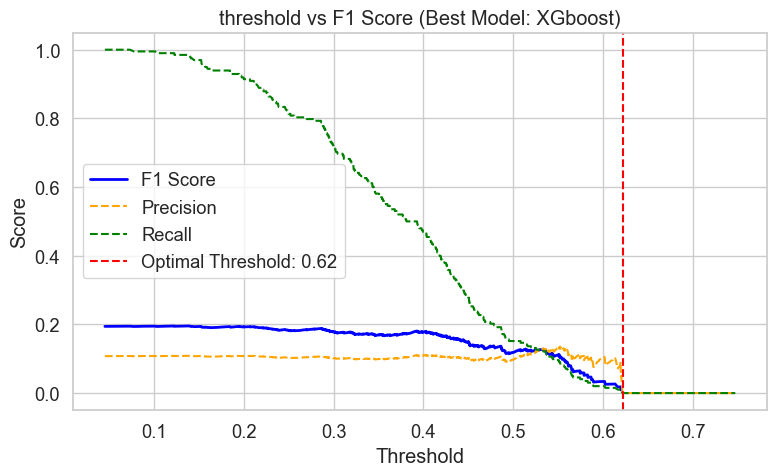

In [15]:
# default threshold = 0.5 and get precison and recall at all thresholds
# test every possible threshold from 0 to 1 and get the precision and recall at each threshold
#(0.01, 0.02...0.99) return an array of all the preciiosn and recal values
precision , recalls, thresholds = precision_recall_curve(y_test, best_proba)


# claculated F1 at each threshold
# why [:-1] threshold array has one less element than precision and recall arrays
f1_scores = 2 * precision[:-1] * recalls[:-1] / (precision[:-1] + recalls[:-1])
# f1_scores = 2 * precision[:-1] * recalls[:-1] / (precision[:-1] + recalls[:-1] + 1e-9)

# find the threshold with max F1
optimal_idx = np.argmax(f1_scores)
optimal_threshold = thresholds[optimal_idx]
optimal_f1 = f1_scores[optimal_idx]


fig, ax = plt.subplots(figsize=(8,5))
ax.plot(thresholds, f1_scores, color="blue", label="F1 Score", linewidth=2)
ax.plot(thresholds, precision[:-1], color="orange", label="Precision", linestyle="--")
ax.plot(thresholds, recalls[:-1], color="green", label="Recall", linestyle="--")

ax.axvline(optimal_threshold, color="red", linestyle="--", label=f"Optimal Threshold: {optimal_threshold:.2f}")
ax.set(title=f"threshold vs F1 Score (Best Model: {best_name})", xlabel="Threshold", ylabel="Score")
ax.legend()

plt.tight_layout()
plt.show()

In [16]:
# whats the probability cutoff to decide if somebdu churned 
# recall how many churner did we catch 

# wide net lower threshold 0.1, 0.2 = many churner caught (high recall) packed alot of false alarm (low precision)

# narrow net higher threshold 0.8, 0.9 = few churner caught (low recall) but fewer false alarm (high precision) 


# precision 
# low threshold = low precision (many false alarm)
# high threshold = high precision (few false alarm)

#f1 score  sweet spot between precision and recall
# f1 score of 1 has a good balance between catching churners and avoiding false alarms

# Step 4 -  Confusion Matrix 

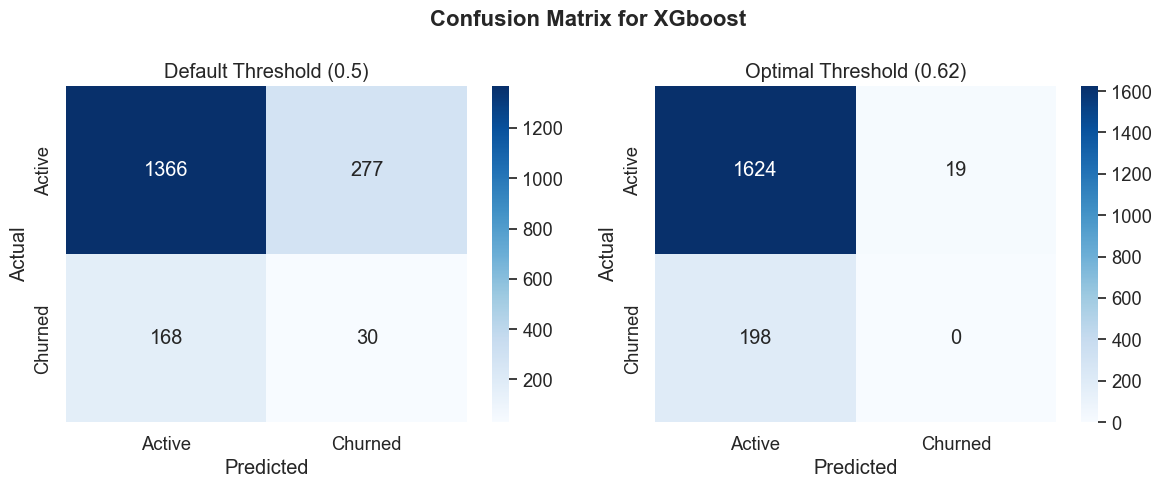

In [17]:
# CONFUSUION MATRIX
# apply the mos toptimal threshold

best_pred_opt = (best_proba >= optimal_threshold).astype(int)
best_prob_def = (best_proba >= 0.5).astype(int)



fig, axes = plt.subplots(1, 2, figsize=(12,5))

for ax, pred, label in zip (
    axes,
    [best_prob_def, best_pred_opt],
    ["Default Threshold (0.5)", f"Optimal Threshold ({optimal_threshold:.2f})"]
):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax, xticklabels=["Active", "Churned"], yticklabels=["Active", "Churned"])
    ax.set(title=label, xlabel="Predicted", ylabel="Actual")


plt.suptitle(f"Confusion Matrix for {best_name}", fontweight="bold", fontsize=16)
plt.tight_layout()
plt.show()

#### 1 - Segment Level performance 
#### 2 -  Feature importance 
#### 3 - Save model & Log experiment

# Step 5 - Segment Level performance 

In [18]:
# segment levele performance
# Does model perform work equally well for our segment?
# champions
# dormant users
# loyal users
# At risk users



test_result = pd.DataFrame({
    "user_id": df["user_id"].values, 
    "y_true": y,
    "y_proba": MODELS[best_name].predict_proba(df[FEATURE_COLS].values)[:,1],

}).merge(segment_df[["user_id", "segment"]], on="user_id", how="left")

test_result["y_pred"] = (test_result["y_proba"] >= optimal_threshold).astype(int)


# Segment performance 

seg_perf = (
    test_result.groupby("segment")
    .apply(lambda g: pd.Series({
        "n_riders": len(g),
        "actual_churn_pct": g["y_true"].mean() * 100,
        "pred_churn_pct": g["y_pred"].mean() * 100,
        "avg_churn_proba": g["y_proba"].mean(),
        "auc": (
            roc_auc_score(g["y_true"], g["y_proba"])
            if g["y_true"].nunique() > 1 else np.nan
        ),
    })).round(2)
)

print(seg_perf.to_string())

              n_riders  actual_churn_pct  pred_churn_pct  avg_churn_proba   auc
segment                                                                        
At-Risk         3523.0             10.64            4.06             0.39  0.89
Champions       3327.0              9.92            5.17             0.37  0.89
Dormant         1766.0             12.17            7.53             0.41  0.90
Loyal Riders     588.0             11.73            8.33             0.33  0.91


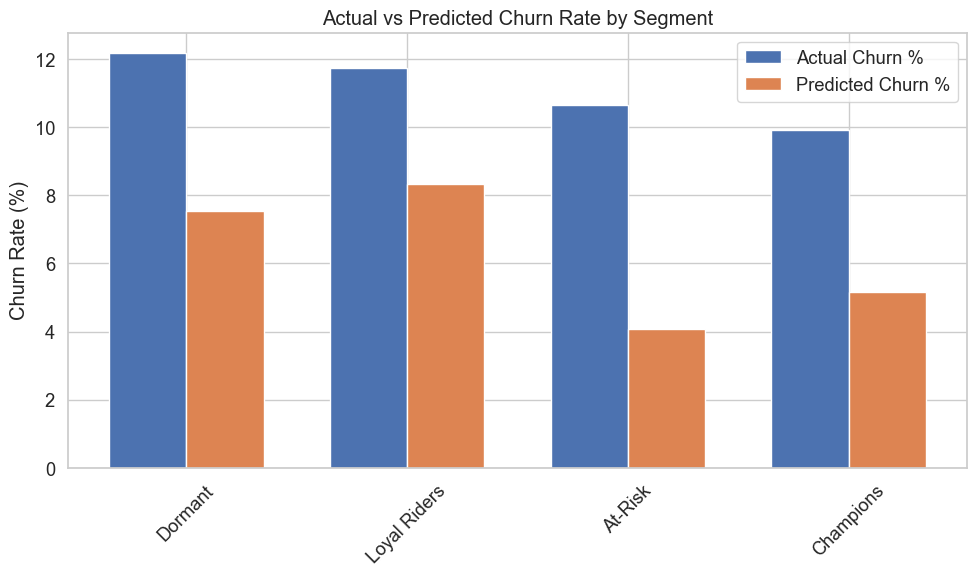

In [19]:
# visualization of segment performance
seg_order = seg_perf["actual_churn_pct"].sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(10,6))
x = np.arange(len(seg_order))
width = 0.35


ax.bar(
    x - width/2, seg_perf.loc[seg_order, "actual_churn_pct"],
    width=width, label="Actual Churn %", edgecolor="white"
)

ax.bar(
    x + width/2, seg_perf.loc[seg_order, "pred_churn_pct"],
    width=width, label="Predicted Churn %", edgecolor="white"
)

ax.set_xticks(x)
ax.set_xticklabels(seg_order, rotation=45)
ax.set(title="Actual vs Predicted Churn Rate by Segment", ylabel="Churn Rate (%)")
ax.legend()
plt.tight_layout()
plt.show()




# Step 6 - Feature Importance  

- which feaures are actually driving churn prediction 

#####

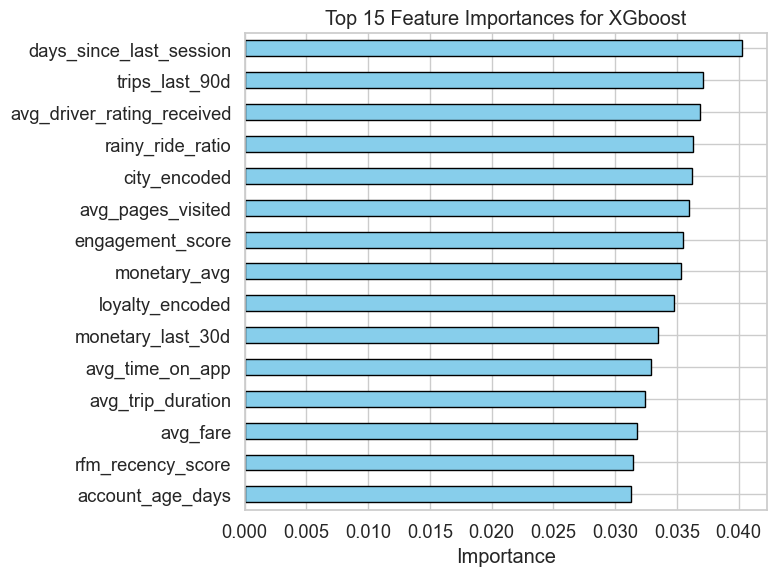

In [20]:
best_model = MODELS[best_name]



if hasattr(best_model, "feature_importances_"):
    importances = (
        pd.Series(best_model.feature_importances_, index=FEATURE_COLS)
        .sort_values(ascending=False).head(15).sort_values()
    )

    fig, ax = plt.subplots(figsize=(8,6))
    importances.plot(kind="barh", ax=ax, color="skyblue", edgecolor="black")
    ax.set(title=f"Top 15 Feature Importances for {best_name}", xlabel="Importance")
    plt.tight_layout()
    plt.show()

else:
    # use absolute coefficients
    coefs = (
        pd.Series(np.abs(best_model.coef_[0]), index=FEATURE_COLS)
        .sort_values(ascending=False).head(15).sort_values()
    )

    fig, ax = plt.subplots(figsize=(8,6))
    coefs.plot(kind="barh", ax=ax, color="salmon", edgecolor="black")
    ax.set(title=f"Top 15 Feature Coefficients for {best_name}", xlabel="Coefficient Magnitude")
    plt.tight_layout()
    plt.show()

# Step 7 : Save models  & Log experiment 




In [21]:
rows = []
for name in MODELS:
    rows.append({
        "model": name,
        "roc_auc": round(roc_auc_score(y_test, probas[name]), 4),
        "f1_def": round(f1_score(y_test, preds[name]), 4),
        "f1_opt": (
            round(f1_score(y_test, (probas[name] >= optimal_threshold).astype(int)), 4)
             if name == best_name else "-"
        ),
        "precision": round(precision_score(y_test, preds[name]), 4),
        "recall": round(recall_score(y_test, preds[name]), 4),
    })

results = pd.DataFrame(rows).set_index("model")
print(results.to_string())

                     roc_auc  f1_def f1_opt  precision  recall
model                                                         
Logistic Regression   0.4708  0.1654      -     0.1016  0.4444
Random Forest         0.4673  0.0000      -     0.0000  0.0000
XGboost               0.4813  0.1188    0.0     0.0977  0.1515


In [23]:
# save these artifacts

joblib.dump(best_model, os.path.join(MODEL_DIR, "churn_model.pkl"))
joblib.dump(FEATURE_COLS, os.path.join(MODEL_DIR, "churn_feature_cols.pkl"))
joblib.dump(optimal_threshold, os.path.join(MODEL_DIR, "churn_optimal_threshold.pkl"))
print("Model artifacts saved successfully!")

Model artifacts saved successfully!
